<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Joint Model Specification

$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

#### NLMEM Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [3]:
import functools

from jax import jit
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc


from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
)


class LogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LogisticMEM_chr6A_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.RealPositive(scale=500),
                mu2=pc.RealPositive(scale=1000),
            ),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(100, 100)),
            var_residual=pc.RealPositive(scale=100),
            alpha=pc.Real(scale=50, shape=(5,)),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        cov_keep: jnp.ndarray,  # shape = (N,5)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve"""
        ksi = cov_keep @ params.alpha + cov @ params.beta + phi1

        out = 100 / (1 + jnp.exp(-(times - ksi[:, None]) / phi2[:, None]))
        assert out.shape == times.shape
        return out

    # ============================================================== #

In [4]:
import pandas as pd
from sdg4varselect.outputs import TestResults

seed_name = "S(1, 9)"
m = LogisticMixedEffectsModel
config = [
    {"N": 220, "J": 18, "P": 1119},
]
results = TestResults(
    [TestResults.load(m(**c), "files", filename_add_on=seed_name) for c in config],
    config,
)
nrun_to_keep = min([len(t) for t in results])
results = TestResults(
    [t.reduce_number_run(nrun_to_keep) for t in results], results.config
)

print(f"chrono = {[str(t.chrono) for t in results]}")
print([len(t) for t in results])


pd.DataFrame(
    [
        [str(t.chrono / t.total_number_res) for t in results],
        [str(t.chrono / len(t[0])) for t in results],
    ],
    index=[
        "by fit",
        f"by estimation ( {results[0].total_number_res/len(results[0])} fits)",
    ],
    columns=[f'N = {c["N"]}, P = {c["P"]}' for c in results.config],
).T

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


files/LogisticMEM_chr6A_N220_J18_P1119_S(1, 9) LOADED !
chrono = ['13 days, 8:58:32.786795']
[9]


,by fit,by estimation ( 40.0 fits)
"N = 220, P = 1119",0:53:29.757741,16:02:55.639340


In [5]:
myModel = m(220, 18, P=max([c["P"] for c in results.config]))
myModel.P

1119

Vérification de la réparition des estimations par rapport à la vraissemblance

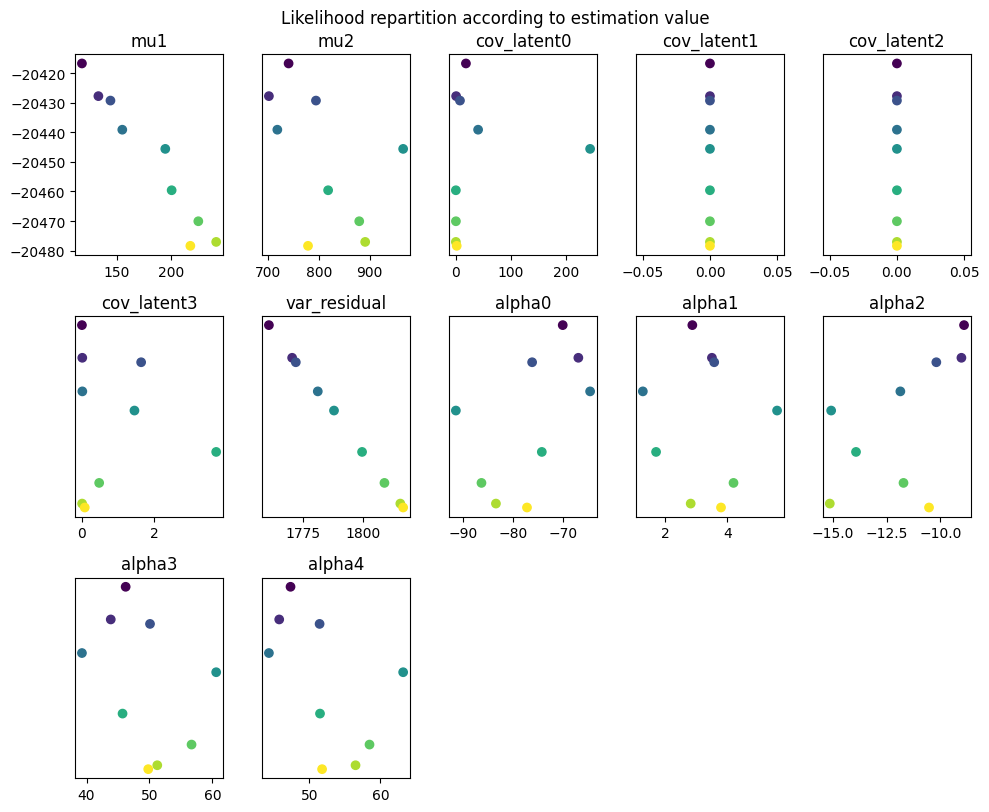

In [6]:
fig = sdgplt.figure(height=8, width=10)
results[-1].sort()

_ = sdgplt.scatter_estimation(
    results[-1].last_theta[:, 1, : myModel.DIM_LD].T,
    results[-1].likelihood[:, 1],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=3,
    ncols=5,
    fig=fig,
)

fig.tight_layout()

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.01)

Regularization path check

In [7]:
from sdg4varselect.outputs import RegularizationPathRes

all_run = results[0]
lbd_set = all_run[0].lbd_set
print(lbd_set.shape)
i_lbd = 0

all_first_run = [[run[0] for run in reg] for reg in all_run]

# first step : for each lbd, choose the estimate of \theta that maximize F - pen

likelihood = jnp.array([[run.likelihood for run in reg] for reg in all_run])
print(likelihood.shape)


pen_estimate = jnp.array([[run.last_theta[0] for run in reg] for reg in all_run])
print(pen_estimate.shape)  # nrun estimate for each lbd

pen = jnp.abs(pen_estimate[:, :, myModel.DIM_LD :]).sum(axis=2)


argmax_pen_estimate = (likelihood[:, :, 0] - lbd_set * pen).argmax(axis=0)
print(argmax_pen_estimate)  # for each lbd best on the nrun estimate
print(argmax_pen_estimate.shape)

best_pen_estimate = jnp.array(
    [pen_estimate[argmax, i] for i, argmax in enumerate(argmax_pen_estimate)]
)

best_pen_estimate.shape

(20,)
(9, 20, 2)
(9, 20, 1131)
[7 1 8 0 5 7 5 1 6 2 4 3 5 2 8 7 8 3 5 6]
(20,)


(20, 1131)

In [8]:
from sdg4varselect.algo import SGD_FIM, get_GDFIM_settings

algo_settings = get_GDFIM_settings(preheating=500, heating=1500, learning_rate=1e-6)


def one_estim(prngkey, model, data):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SGD_FIM(prngkey_estim, 2000, algo_settings)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5, "phi2": 20})

    for var_lat in algo.latent_variables.values():
        var_lat.adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=False)

    return res

In [9]:
from sdg4varselect._estimation_method import _estim_shrink_model
from model import myModel, data

# estim = [
#     _estim_shrink_model(
#         one_estim,
#         jrd.PRNGKey(i),
#         myModel,
#         data,
#         theta_first_estim=best_pen_estimate[i],
#     )
#     for i in range(len(best_pen_estimate))
# ]

P = 1119, N = 220


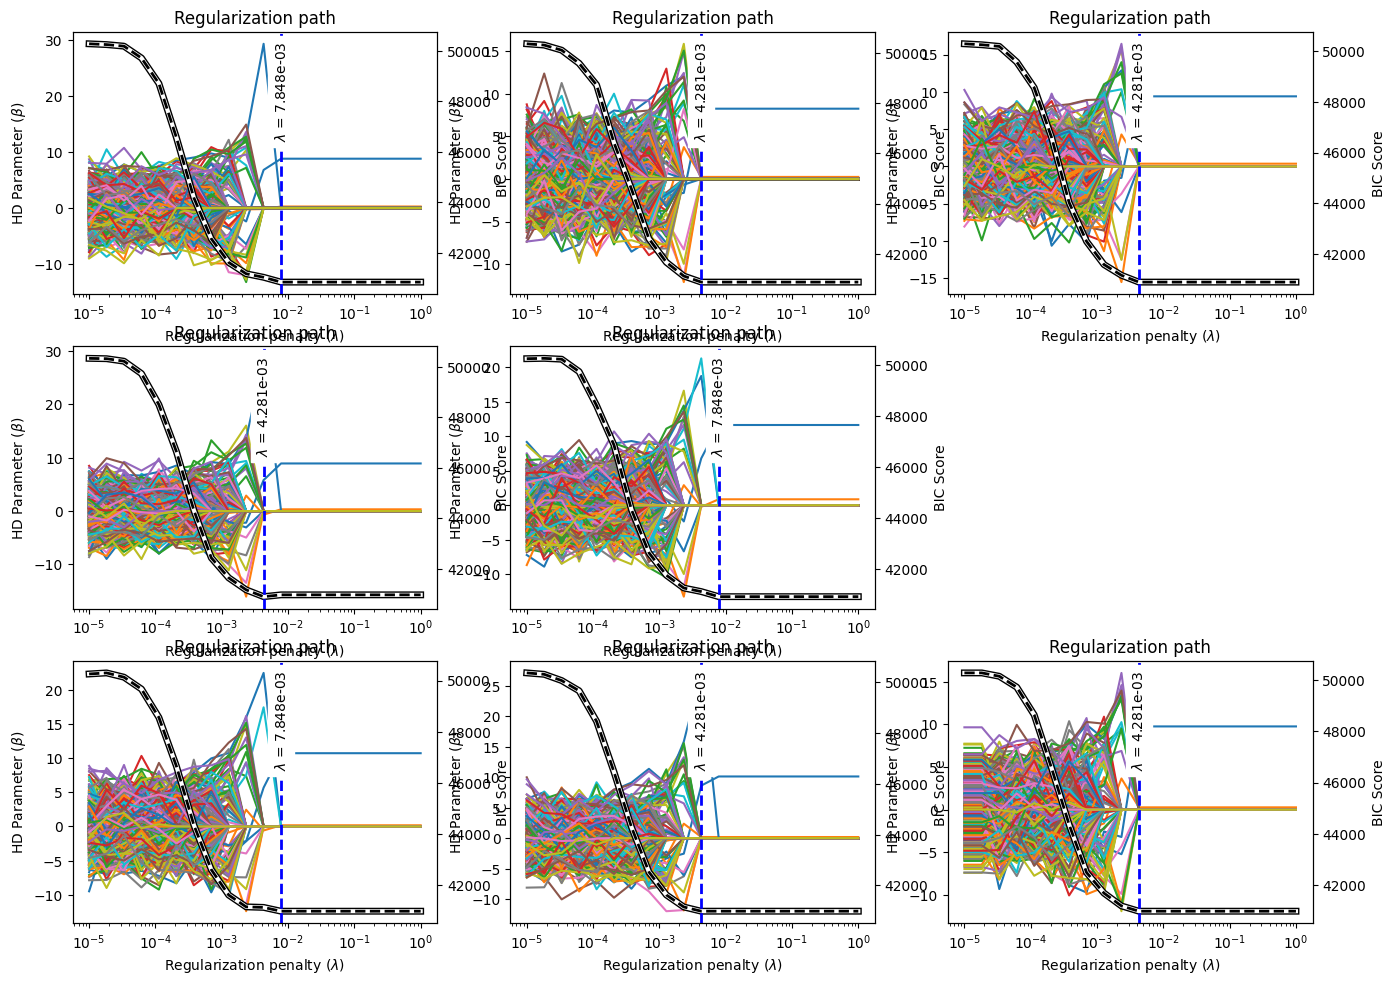

In [43]:
from sdg4varselect._regularization_function import eBIC


step = 1

id = [[1, 2, 3], [4, 5], [7, 8, 9]]

fig = sdgplt.figure(32, 16)
for i in range(len(id)):
    for j in range(len(id[i])):
        ii = id[i][j] - 1

        reg_res = results[0][ii].standardize()
        ax = fig.add_subplot(
            sum([len(iid) for iid in id]), max([len(iid) for iid in id]), ii + 1
        )
        _ = sdgplt.plot_reg_path(reg_res=reg_res, dim_ld=myModel.DIM_LD, ax=ax)


# for t in range(len(results[0])):
#     reg_res = results[0][t].standardize()  # .filter(P=300)[0]
#     print(reg_res.last_theta[1, myModel.DIM_LD :])
#     fig = sdgplt.plot_reg_path(
#         reg_res=reg_res, dim_ld=myModel.DIM_LD, fig=sdgplt.figure(5, 5)
#     )
# ax = fig.axes[0]

# x = jnp.array([r.last_theta[step, myModel.DIM_LD :] for r in reg_res])
# t = jnp.array([xx[~jnp.isnan(xx)] for xx in x])

# ebic = eBIC(
#     t,
#     jnp.array([r.likelihood[step] for r in reg_res]),
#     myModel.N * (1 + myModel.J),
# )

# sdgplt._plot_bic(
#     ax=ax,
#     lbd_set=reg_res.lbd_set,
#     bic=ebic,
#     argmin_bic=jnp.argmin(ebic),
#     colors=["r", "b", "r"],
#     msg="eBIC",
# )

# ax.legend()

['$\\mu_1$' '$\\mu_2$' '$\\gamma^2_1$' '$\\gamma^2_{12}$' '$\\sigma^2$'
 '$\\alpha_1$' '$\\alpha_2$' '$\\alpha_3$' '$\\alpha_4$' '$\\alpha_5$'
 '$\\beta_1$' '$\\beta_2$' '$\\beta_3$' '$\\beta_4$' '$\\beta_5$']


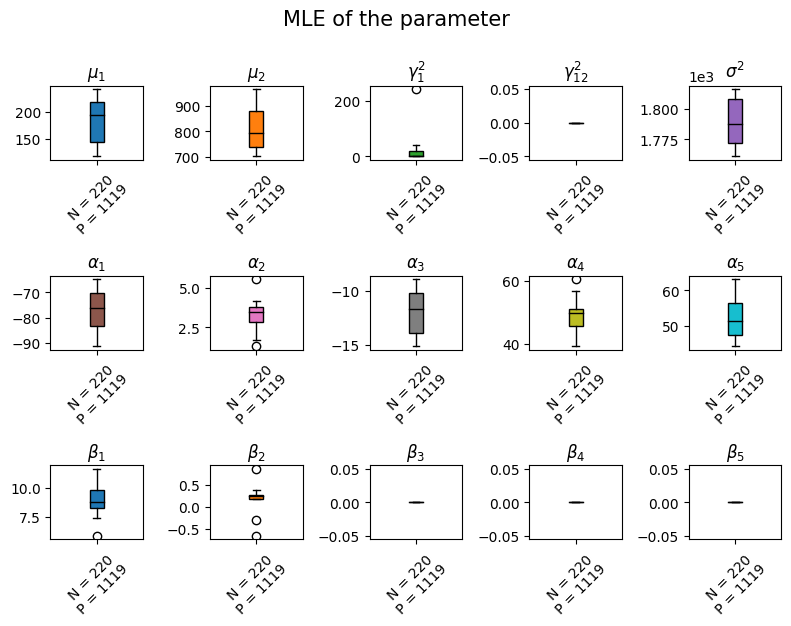

In [19]:
import numpy as np

params_names = np.array(
    [
        "$\\mu_1$",
        "$\\mu_2$",
        "$\\gamma^2_1$",
        "$\\gamma^2_{12}$",
        "$\\gamma^2_{21}$",
        "$\\gamma^2_2$",
        "$\\sigma^2$",
    ]
    + [f"$\\alpha_{i+1}$" for i in range(5)]
    + [f"$\\beta_{i+1}$" for i in range(myModel.P)]
)

r = results  # [0]  # .filter(P=500, N=200)

scenarios_labels = [
    f"{n}\n{p}"
    for n, p in zip(r.get_scenarios_labels("N"), r.get_scenarios_labels("P"))
]
id = np.array([1, 2, 3, 4] + [7 + i for i in range(11)]) - 1

print(params_names[id])
x = r.last_theta[:, :, -1, id]
fig = sdgplt.boxplot_estimation(
    x=x.T,
    xlabels=scenarios_labels,
    title=params_names[id],
    nrows=4,
    ncols=5,
    fig=sdgplt.figure(height=7, width=8),
)

for ax in fig.axes:
    ax.tick_params(axis="x", labelrotation=45)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

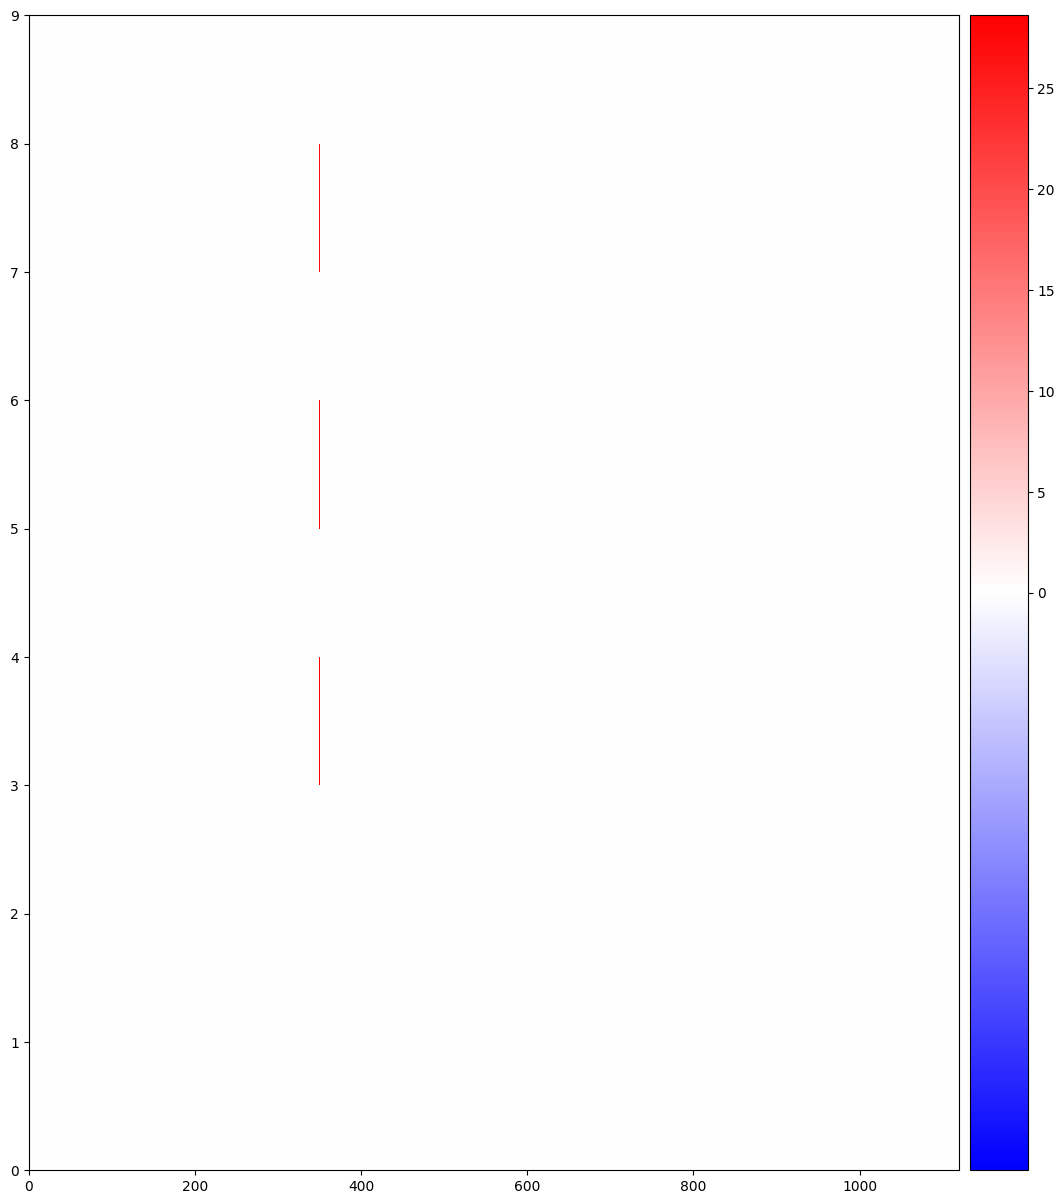

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

theta = jnp.array(
    [
        jnp.array([(res[-1][myModel.DIM_LD :]) for res in test])
        for test in results.last_theta
    ]
)[1]

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)


def meshgrid(ax, dt):
    x_abs = 0.5 + np.arange(dt.shape[1])
    y_ord = 0.5 + np.arange(dt.shape[0])
    x, y = np.meshgrid(x_abs, y_ord)

    vmin = dt.min() if dt.min() < 0 else -0.001
    vmax = dt.max() if dt.max() > 0 else 0.0001

    colormesh = ax.pcolormesh(
        x,
        y,
        dt,
        cmap=plt.colormaps["bwr"],
        norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    )

    # ax.set_aspect("equal")

    # cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    cb = fig.colorbar(colormesh, ax=ax)  # , location="right")

    return ax, cb


ax, cb = meshgrid(ax, theta)
cb_pos = cb.ax.get_position()
ax_pos = ax.get_position()
cb.ax.set_position([ax_pos.xmax * 1.01, ax_pos.ymin, ax_pos.width, ax_pos.height])

### Variable selection numerical proof

In [17]:
def get_support(x):
    if len(x.shape) > 1:
        return jnp.array([get_support(xx) for xx in x])

    return jnp.where(jnp.isnan(x), jnp.nan, x != 0)


multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :])
print(multi_support.shape)

(1, 9, 1119)


In [61]:
x = get_support(jnp.array([run.last_theta[-1, myModel.DIM_LD :] for run in results[0]]))
print(x.shape)

argmin_bic = [run.argmin_bic for run in results[0]]
print(argmin_bic)

(9, 1119)
[Array(11, dtype=int64), Array(19, dtype=int64), Array(14, dtype=int64), Array(10, dtype=int64), Array(12, dtype=int64), Array(10, dtype=int64), Array(11, dtype=int64), Array(10, dtype=int64), Array(11, dtype=int64)]


In [58]:
x = get_support(jnp.array([run.last_theta[-1, myModel.DIM_LD :] for run in results[0]]))

print(x.shape)
print(x)

[jnp.where(x[i]) for i in range(x.shape[0])]

(9, 1119)
[[1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 ...
 [1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 0. 0.]]


[(Array([0, 1], dtype=int64),),
 (Array([0, 1], dtype=int64),),
 (Array([0, 1], dtype=int64),),
 (Array([  0,   1, 350], dtype=int64),),
 (Array([0, 1], dtype=int64),),
 (Array([  0,   1, 350], dtype=int64),),
 (Array([0, 1], dtype=int64),),
 (Array([  0,   1, 350], dtype=int64),),
 (Array([0, 1], dtype=int64),)]

In [24]:
x = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :])
x

Array([[[1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        ...,
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.]]], dtype=float64)

[[2. 2. 2. 3. 2. 3. 2. 3. 2.]]


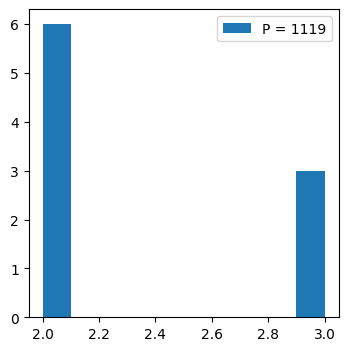

In [18]:
def hist(results):
    multi_support = get_support(results.last_theta[:, :, -1, myModel.DIM_LD :])
    ax = sdgplt.get_ax(4, 4)
    print(jnp.nansum(multi_support, axis=-1))
    h = ax.hist(
        jnp.nansum(multi_support, axis=-1), label=results.get_scenarios_labels("P")
    )
    ax.legend()


hist(results)